# Notebook 7 — Final Comparison

This notebook compares the recommendation results before and after adding predicted ratings for previously unrated courses.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'

sys.path.append(str(PROJECT_ROOT))
import utils_recommender as ur
ur.ensure_dirs(FIGURES_DIR, MODELS_DIR, RESULTS_DIR)

In [2]:
cb_before = pd.read_csv(RESULTS_DIR / 'results_content_based_before.csv', index_col=0)
cb_after = pd.read_csv(RESULTS_DIR / 'results_content_based_after.csv', index_col=0)
cf_before = pd.read_csv(RESULTS_DIR / 'results_collaborative_before.csv', index_col=0)
cf_after = pd.read_csv(RESULTS_DIR / 'results_collaborative_after.csv', index_col=0)

cb_plot = pd.concat([cb_before.assign(Stage='Before'), cb_after.assign(Stage='After')]).reset_index().rename(columns={'index':'Algorithm'})
cf_plot = pd.concat([cf_before.assign(Stage='Before'), cf_after.assign(Stage='After')]).reset_index().rename(columns={'index':'Algorithm'})

cb_plot.head(), cf_plot.head()

(  Algorithm    RMSE     MAE  HitRate@10  Precision@10  Recall@10  NDCG@10  \
 0    TF-IDF  0.0196  0.0010      0.5033        0.0580     0.2958   0.1980   
 1       BoW  0.0199  0.0010      0.4500        0.0510     0.2632   0.1851   
 2    TF-IDF  0.0547  0.0052      0.4700        0.0557     0.2923   0.1817   
 3       BoW  0.0590  0.0059      0.3967        0.0490     0.2623   0.1691   
 
    Coverage   Stage  
 0    0.4104  Before  
 1    0.4104  Before  
 2    1.0000   After  
 3    1.0000   After  ,
   Algorithm    RMSE     MAE  HitRate@10  Precision@10  Recall@10  NDCG@10  \
 0  User-KNN  0.0693  0.0213      0.6081        0.0831     0.4855   0.2871   
 1  Item-KNN  0.0624  0.0039      0.3311        0.0372     0.2213   0.1189   
 2  User-KNN  0.0287  0.0135      0.7124        0.0882     0.5883   0.3397   
 3  Item-KNN  0.0161  0.0014      0.3203        0.0359     0.2110   0.1279   
 
    Coverage   Stage  
 0    0.7698  Before  
 1    0.9048  Before  
 2    0.3420   After  
 3    0.

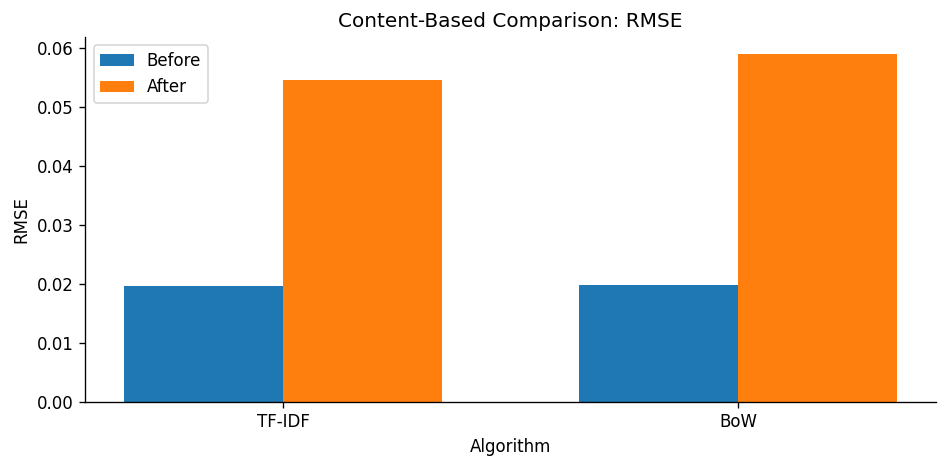

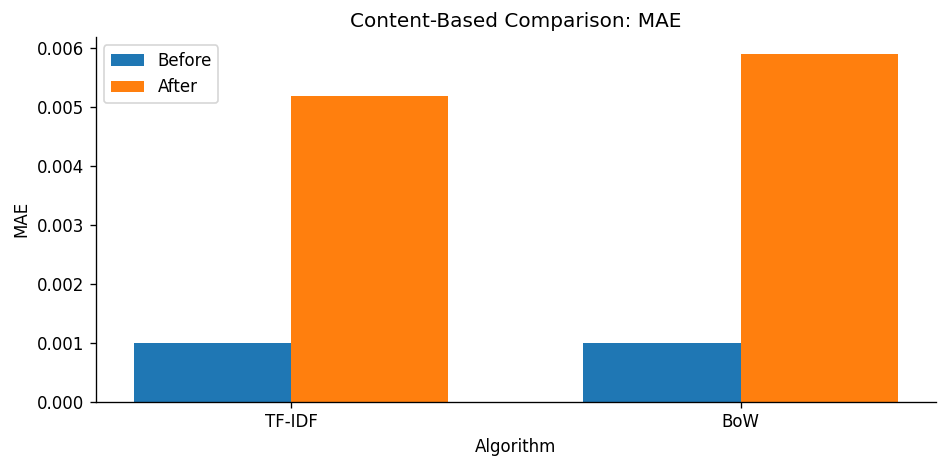

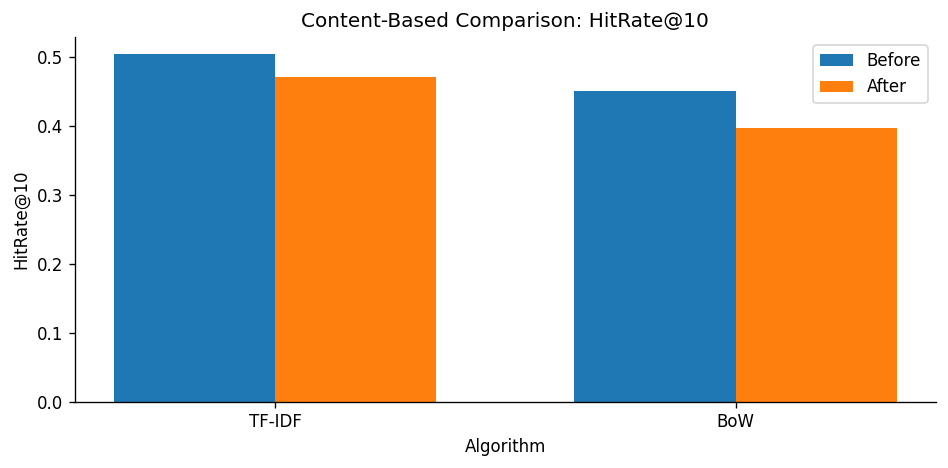

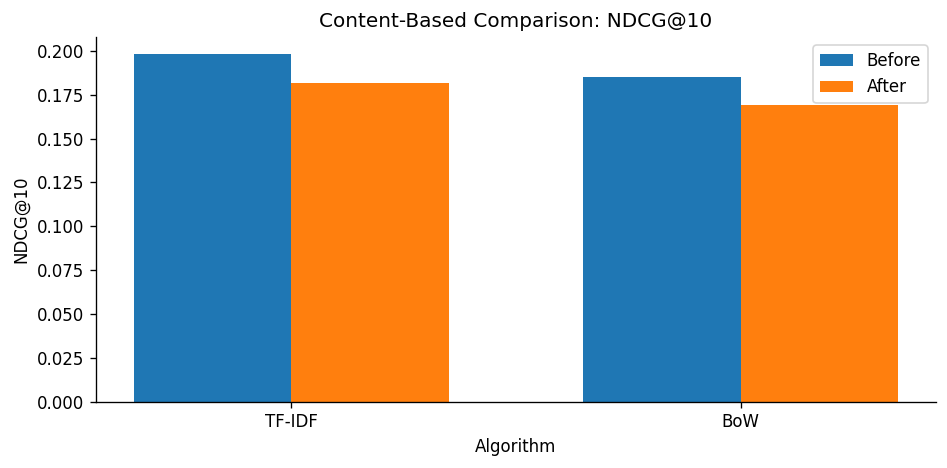

In [3]:
for metric in ['RMSE', 'MAE', 'HitRate@10', 'NDCG@10']:
    plt.figure(figsize=(8,4))

    before_vals = cb_plot[cb_plot['Stage']=='Before'][metric].values
    after_vals = cb_plot[cb_plot['Stage']=='After'][metric].values
    labels = cb_plot[cb_plot['Stage']=='Before']['Algorithm'].values

    x = np.arange(len(labels))
    width = 0.35

    plt.bar(x - width/2, before_vals, width, label='Before')
    plt.bar(x + width/2, after_vals, width, label='After')

    plt.xticks(x, labels)
    plt.xlabel('Algorithm')
    plt.ylabel(metric)
    plt.title(f'Content-Based Comparison: {metric}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'comparison_content_{metric}.png')
    plt.show()

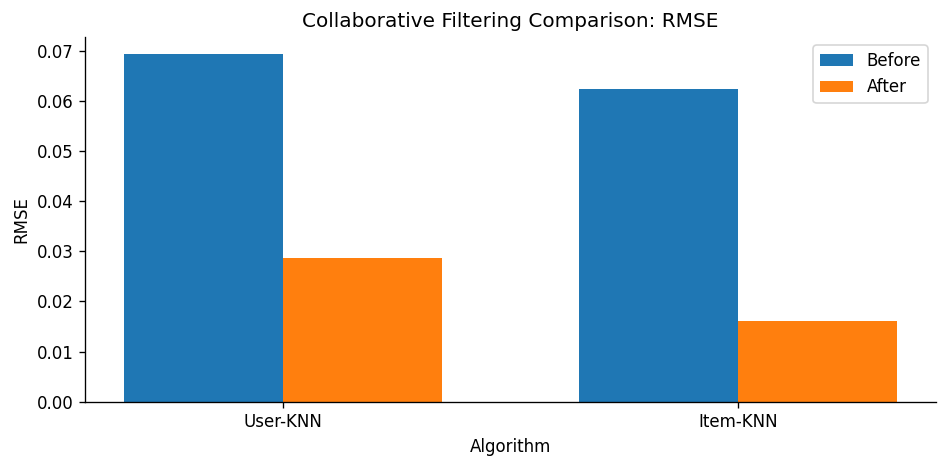

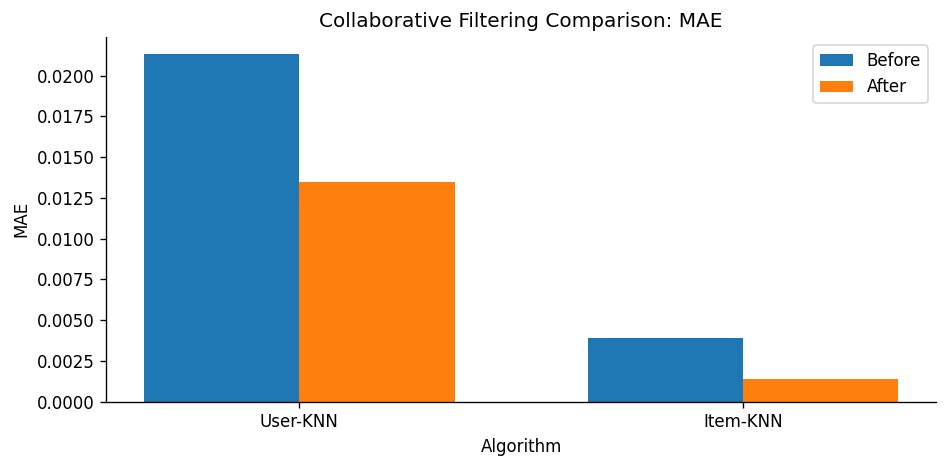

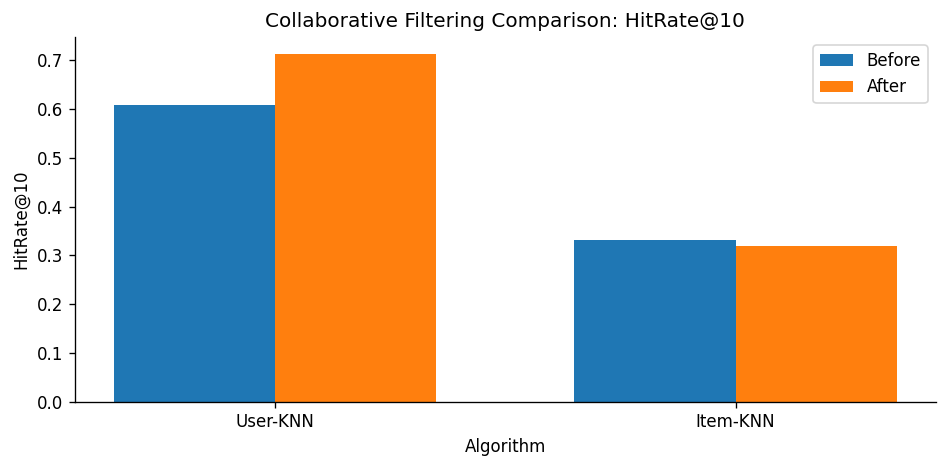

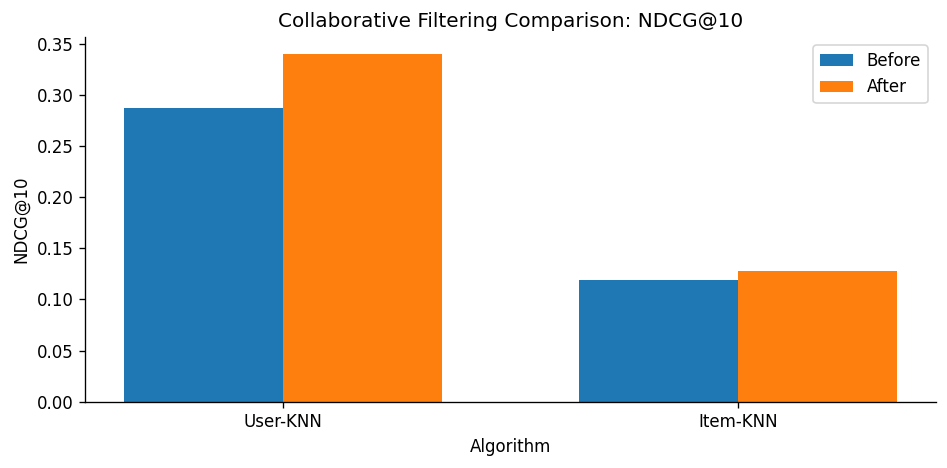

In [4]:
for metric in ['RMSE', 'MAE', 'HitRate@10', 'NDCG@10']:
    plt.figure(figsize=(8,4))

    before_vals = cf_plot[cf_plot['Stage']=='Before'][metric].values
    after_vals = cf_plot[cf_plot['Stage']=='After'][metric].values
    labels = cf_plot[cf_plot['Stage']=='Before']['Algorithm'].values

    x = np.arange(len(labels))
    width = 0.35

    plt.bar(x - width/2, before_vals, width, label='Before')
    plt.bar(x + width/2, after_vals, width, label='After')

    plt.xticks(x, labels)
    plt.xlabel('Algorithm')
    plt.ylabel(metric)
    plt.title(f'Collaborative Filtering Comparison: {metric}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'comparison_cf_{metric}.png')
    plt.show()

In [5]:
summary_rows = []

for alg in cb_before.index:
    summary_rows.append({
        'Family': 'Content-Based',
        'Algorithm': alg,
        'RMSE_Before': cb_before.loc[alg, 'RMSE'],
        'RMSE_After': cb_after.loc[alg, 'RMSE'],
        'MAE_Before': cb_before.loc[alg, 'MAE'],
        'MAE_After': cb_after.loc[alg, 'MAE'],
        'HitRate_Before': cb_before.loc[alg, 'HitRate@10'],
        'HitRate_After': cb_after.loc[alg, 'HitRate@10'],
        'NDCG_Before': cb_before.loc[alg, 'NDCG@10'],
        'NDCG_After': cb_after.loc[alg, 'NDCG@10'],
        'Coverage_Before': cb_before.loc[alg, 'Coverage'],
        'Coverage_After': cb_after.loc[alg, 'Coverage']
    })

for alg in cf_before.index:
    summary_rows.append({
        'Family': 'Collaborative Filtering',
        'Algorithm': alg,
        'RMSE_Before': cf_before.loc[alg, 'RMSE'],
        'RMSE_After': cf_after.loc[alg, 'RMSE'],
        'MAE_Before': cf_before.loc[alg, 'MAE'],
        'MAE_After': cf_after.loc[alg, 'MAE'],
        'HitRate_Before': cf_before.loc[alg, 'HitRate@10'],
        'HitRate_After': cf_after.loc[alg, 'HitRate@10'],
        'NDCG_Before': cf_before.loc[alg, 'NDCG@10'],
        'NDCG_After': cf_after.loc[alg, 'NDCG@10'],
        'Coverage_Before': cf_before.loc[alg, 'Coverage'],
        'Coverage_After': cf_after.loc[alg, 'Coverage']
    })

comparison_summary = pd.DataFrame(summary_rows)
comparison_summary.to_csv(RESULTS_DIR / 'final_comparison_summary.csv', index=False)

comparison_summary

,Family,Algorithm,RMSE_Before,RMSE_After,MAE_Before,MAE_After,HitRate_Before,HitRate_After,NDCG_Before,NDCG_After,Coverage_Before,Coverage_After
0,Content-Based,TF-IDF,0.0196,0.0547,0.0010,0.0052,0.5033,0.4700,0.1980,0.1817,0.4104,1.0000
1,Content-Based,BoW,0.0199,0.0590,0.0010,0.0059,0.4500,0.3967,0.1851,0.1691,0.4104,1.0000
2,Collaborative Filtering,User-KNN,0.0693,0.0287,0.0213,0.0135,0.6081,0.7124,0.2871,0.3397,0.7698,0.3420
3,Collaborative Filtering,Item-KNN,0.0624,0.0161,0.0039,0.0014,0.3311,0.3203,0.1189,0.1279,0.9048,0.3844
